In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [2]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("saved_vars*.pickle"))
# all_model_results

In [3]:
## Get projector sizes from configs 
configs_egs = list(Path('model_configs/barlow_search').glob("*audioset*hparam_set*_lr*.yaml"))

proj_size_dict = {}
for config_path in configs_egs:
    config = yaml.load(open(config_path), Loader=yaml.FullLoader)
    # get hpara_str for mapping
    hpara_str = "base_arch"
    if 'hparam_set' in str(config_path):
        hpara_int = int(re.search(r'hparam_set_(\d+)_', config_path.stem).group(1))
        hpara_str = f"hparam_set_{hpara_int:02d}"
    # get projector size 
    projector_dims = config['model']['arch_kwargs']['projector_dims']
    proj_size_dict[hpara_str] = projector_dims
    

proj_size_dict['base_arch'] = [512, 512]

In [8]:
test_layers = [
            'input_after_preproc',
            'conv1',
            'bn1',
            'conv1_relu1',
            'maxpool1',
            'layer1',
            'layer2',
            'layer3',
            'layer4',
            'avgpool',
        ]


def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    task = None
    for task_str in ['word', 'audioset', 'dual', 'word_audioset']:

        if task_str in path_str:
            if task_str == 'dual':
                task = 'word_audioset'
            else:
                task = task_str 
    hpara_str = "base_arch"
    if 'hparam_set' in path_str:
        hpara_int = int(re.search(r'hparam_set_(\d+)_', path_str).group(1))
        hpara_str = f"hparam_set_{hpara_int:02d}"

    loss = [loss for loss in ['mmcr', 'barlow', 'simclr'] if loss in path_str]
    if len(loss) > 0:
        loss = loss[0]
    else:
        if 'ssl' in path_str:
            loss = 'mmcr'
        else:
            loss = 'cross_ent'

    test_layer = [layer for layer in test_layers if layer in path_str][0]

    ckpt = '_best_val_ckpt' if 'ckpt' in path_str else ''
    lr_str = ""
    if 'lr' in path_str:
        try:
            lr_int = int(re.search(r'lr_(\d+)', path_str).group(1))
            lr_str = f"_lr_{lr_int:02d}"
        except:
            pass

    model_name = f"{task}_{hpara_str}{lr_str}_{loss}_{test_layer}{ckpt}"
    return model_name, task, hpara_str, loss, test_layer



## Plot model summaries - overall vs task, layer size, etc

In [26]:
test_layers = [
            'input_after_preproc',
            'conv1',
            'bn1',
            'conv1_relu1',
            'maxpool1',
            'layer1',
            'layer2',
            'layer3',
            'layer4',
            'avgpool',
        ]
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name = results_path.parent.stem.split("_nact")[0]
    _, task, hpara_str, loss, test_layer = format_model_str(results_path)
    if loss == 'cross_ent':
        proj_dim = 'None'
    else:
        proj_dim = f"{proj_size_dict[hpara_str]}"

    train_set = "Matched w RandomCrop" if 'Matched' in str(results_path) else "Precombined" 
    
    data = dict(model_name=model_name, task=task, hpara_str=hpara_str, loss=loss, test_layer=test_layer, overall_acc=overall_acc, proj_dim=proj_dim, train_set=train_set)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    
    if 'projects' in str(results_path):
        continue 
    
    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)
df = pd.DataFrame.from_records(df_list)
df['test_layer'] = df['test_layer'].astype('str')

/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


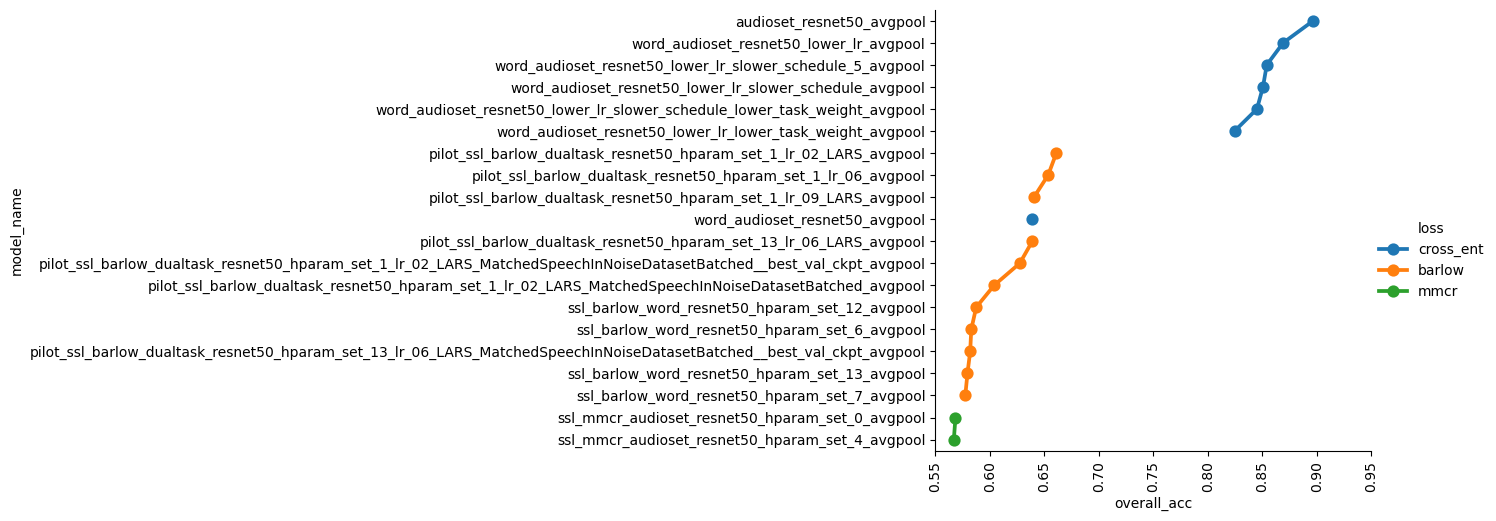

In [44]:
g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False).iloc[:20], kind='point', x='overall_acc', y='model_name',hue='loss', height=5)
g.set_xticklabels(rotation=90)


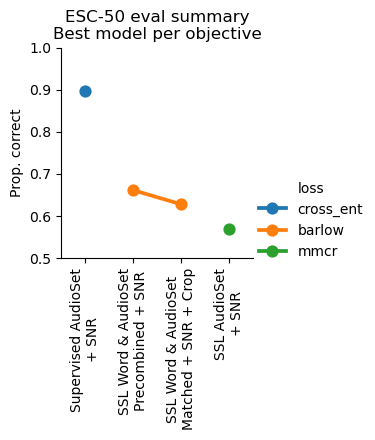

In [95]:
# Get best models from each set 
losses = ['cross_ent', 'mmcr', 'barlow']
wanted_models = ["pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool"]
for loss in losses:
    wanted_models.append(df[(df.loss == loss) & (df.test_layer == 'avgpool')].sort_values('overall_acc', ascending=False).iloc[0, 0])

plot_name_dict = {
    'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool': "SSL Word & AudioSet\nMatched + SNR + Crop",
    'audioset_resnet50_avgpool': "Supervised AudioSet\n+ SNR",
    'ssl_mmcr_audioset_resnet50_hparam_set_0_avgpool': "SSL AudioSet\n+ SNR",
    'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_avgpool' : "SSL Word & AudioSet\nPrecombined + SNR"
}
to_plot = df[df.model_name.isin(wanted_models)].sort_values('overall_acc', ascending=False)
to_plot['plot_name'] = to_plot.model_name.map(plot_name_dict)
g= sns.catplot(data=to_plot, x='plot_name',# order=['cross_ent', 'barlow', 'mmcr'],
                y='overall_acc', hue='loss', kind='point', height=3, aspect=1)
g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nBest model per objective', ylim=(.5,1) )


In [13]:
# sns.catplot(data=df[df.loss == 'barlow'].sort_values('overall_acc', ascending=False), kind='point', x='overall_acc', y='model_name', hue='model_name', height=9, aspect=.25)
# plt.tight_layout()

df[df.loss == 'barlow'].sort_values('overall_acc', ascending=False).iloc[:10]

,model_name,task,hpara_str,loss,test_layer,overall_acc,proj_dim,train_set
45,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset,hparam_set_01,barlow,avgpool,0.6610,"[512, 512]",Precombined
28,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset,hparam_set_01,barlow,avgpool,0.6535,"[512, 512]",Precombined
73,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset,hparam_set_01,barlow,avgpool,0.6405,"[512, 512]",Precombined
51,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset,hparam_set_13,barlow,avgpool,0.6390,"[8192, 512]",Precombined
56,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset,hparam_set_01,barlow,avgpool,0.6275,"[512, 512]",Matched w RandomCrop
43,ssl_barlow_word_resnet50_hparam_set_15_layer2,word,hparam_set_15,barlow,layer2,0.6250,"[8192, 2048]",Precombined
25,ssl_barlow_word_resnet50_hparam_set_3_layer2,word,hparam_set_03,barlow,layer2,0.6190,"[512, 2048]",Precombined
126,ssl_barlow_word_resnet50_hparam_set_0_layer2,word,hparam_set_00,barlow,layer2,0.6175,"[512, 512]",Precombined
8,ssl_barlow_word_resnet50_hparam_set_9_layer2,word,hparam_set_09,barlow,layer2,0.6135,"[2048, 2048]",Precombined
97,ssl_barlow_word_resnet50_hparam_set_1_layer2,word,hparam_set_01,barlow,layer2,0.6105,"[512, 512]",Precombined


In [14]:
df[(df.loss == 'mmcr') & (df.test_layer == 'avgpool')].sort_values('overall_acc', ascending=False).iloc[:10].model_name.values

array(['ssl_mmcr_audioset_resnet50_hparam_set_0_avgpool',
       'ssl_mmcr_audioset_resnet50_hparam_set_4_avgpool',
       'ssl_mmcr_audioset_resnet50_hparam_set_2_avgpool',
       'ssl_mmcr_audioset_resnet50_hparam_set_16_avgpool',
       'pilot_ssl_audioset_resnet50_avgpool',
       'pilot_ssl_mmcr_dualtask_resnet50_hparam_set_1_lr_06_avgpool',
       'ssl_mmcr_audioset_resnet50_hparam_set_6_avgpool',
       'ssl_mmcr_word_resnet50_hparam_set_12_avgpool',
       'ssl_mmcr_audioset_resnet50_hparam_set_10_avgpool',
       'ssl_mmcr_audioset_resnet50_hparam_set_8_avgpool'], dtype=object)

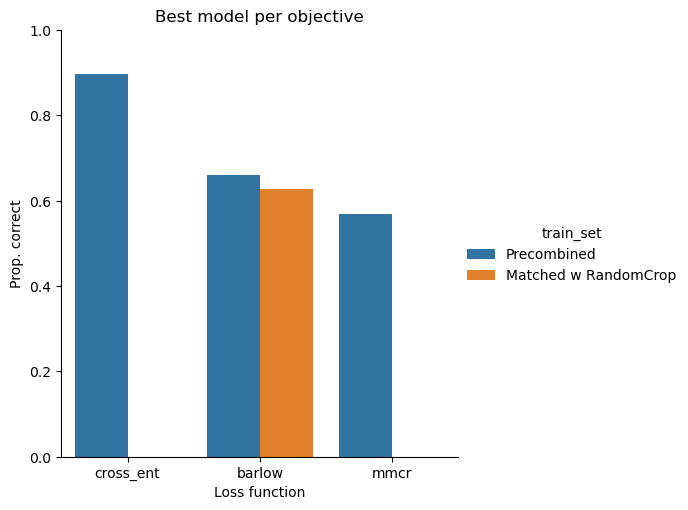

In [42]:
# Get best models from each set 
losses = ['cross_ent', 'mmcr', 'barlow']
wanted_models = ["pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool"]
for loss in losses:
    wanted_models.append(df[(df.loss == loss) & (df.test_layer == 'avgpool')].sort_values('overall_acc', ascending=False).iloc[0, 0])

to_plot = df[df.model_name.isin(wanted_models)]
g= sns.catplot(data=to_plot, x="loss", order=['cross_ent', 'barlow', 'mmcr'],
                y='overall_acc', hue='train_set', kind='bar')
g.set(xlabel='Loss function', ylabel='Prop. correct', title='Best model per objective', ylim=(0,1))


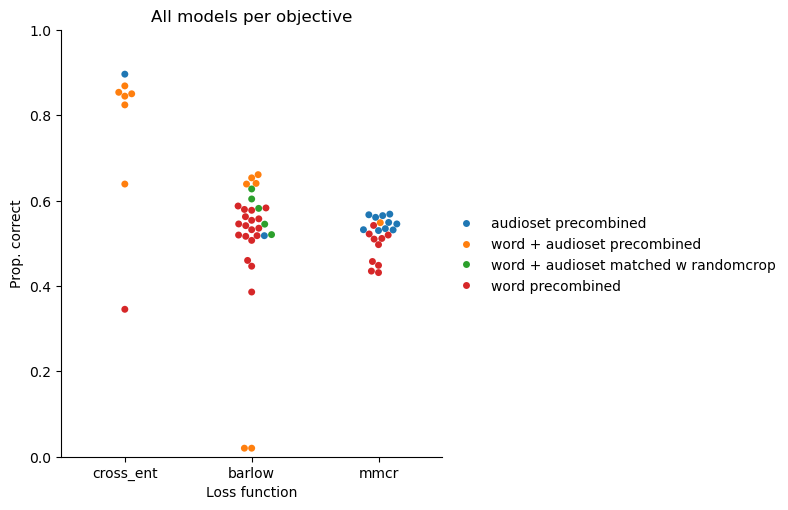

In [18]:
# sns.set_context('talk')
## Compare Datasets 
to_plot = df[(df.test_layer == 'avgpool') & (df.model_name != 'word_base_arch_cross_ent_avgpool')].copy()
to_plot['train_task'] = to_plot['task'].str.replace("_", " + ") + ' ' + to_plot['train_set'].str.lower()
hue_order = ['audioset precombined',
        'word + audioset precombined',
       'word + audioset matched w randomcrop',
       'word precombined', 
       ]
g = sns.catplot(data=to_plot,
               kind="swarm",
                y='overall_acc',
                 x='loss', order=['cross_ent', 'barlow', 'mmcr'],
                  hue='train_task', hue_order=hue_order)


g.set(xlabel='Loss function', ylabel='Prop. correct', title='All models per objective', ylim=(0,1))
g.legend.set_title(title='')

Text(0.5, 1.05, 'All models per objective')

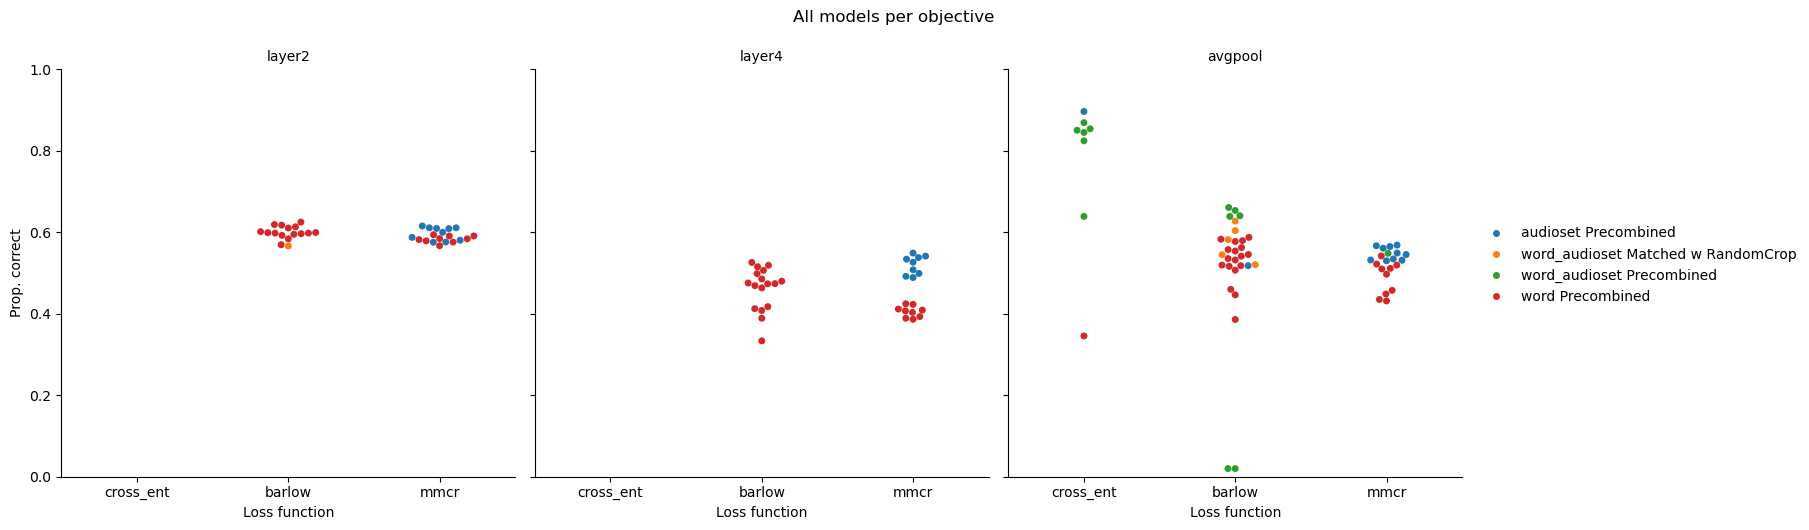

In [19]:
# sns.set_context('talk')
## Compare Datasets 
to_plot = df[ (df.model_name != 'word_base_arch_cross_ent_avgpool')].copy()
to_plot['train_task'] = to_plot['task'] + ' ' + to_plot['train_set']
g = sns.catplot(data=to_plot,
               kind="swarm",
                y='overall_acc',
                col = 'test_layer', col_order=['layer2',  'layer4', 'avgpool'],
                x='loss', order=['cross_ent', 'barlow', 'mmcr'],
                hue='train_task')
                # title='All models per objective',

g.set_titles('{col_name}')
g.set(xlabel='Loss function', ylabel='Prop. correct', ylim=(0,1))
g.legend.set_title(title='')
plt.suptitle('All models per objective', y=1.05)

/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


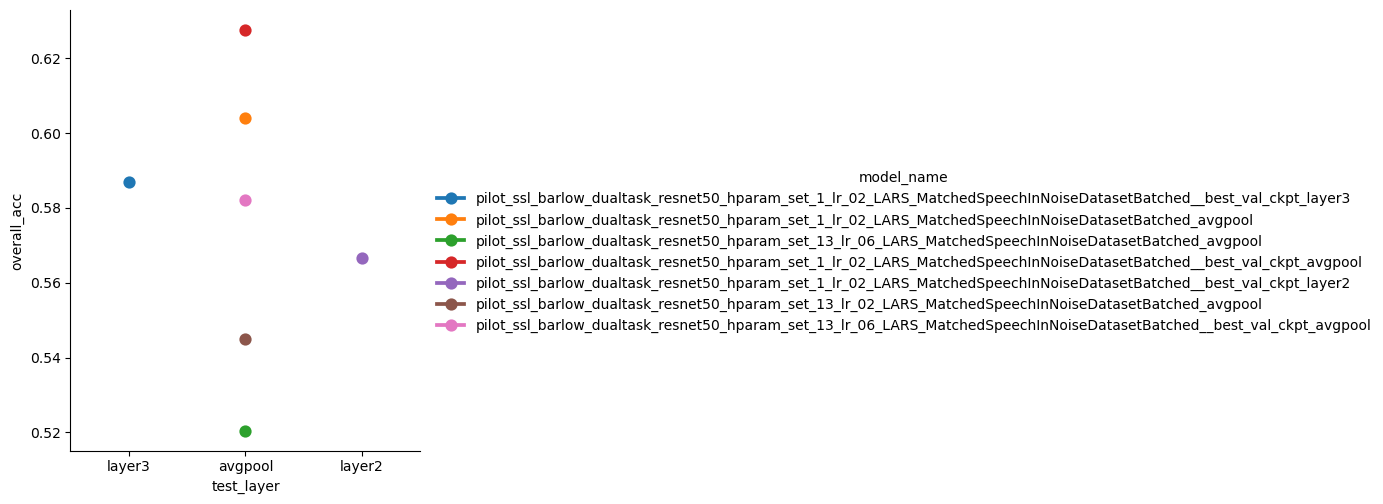

In [22]:
## Compare Datasets 
to_plot = df[df.train_set == 'Matched w RandomCrop']

g = sns.catplot(data=to_plot, kind="point", y='overall_acc', x='test_layer', hue='model_name')

Text(47.367825038580236, 0.5, 'Prop. correct')

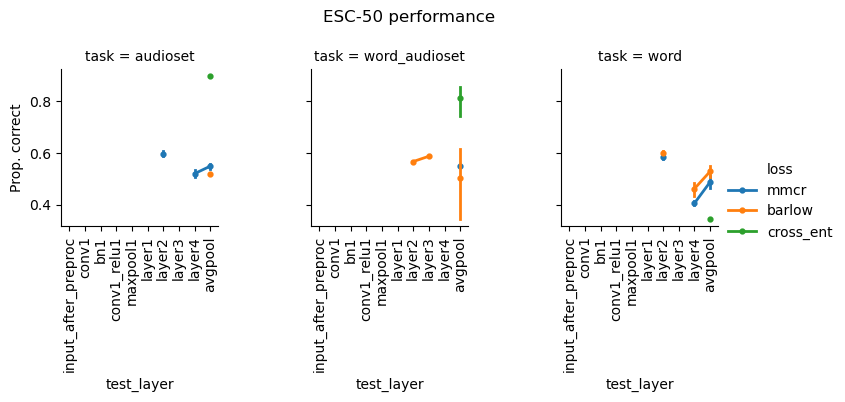

In [21]:
g = sns.catplot(data=df, y='overall_acc', kind='point', x='test_layer', col='task', hue='loss', order=test_layers, height=2.5, linewidth=2,  markersize=3,)
g.set_xticklabels(rotation=90)
plt.suptitle('ESC-50 performance' ,y=1.1)
g.axes[0][0].set_ylabel('Prop. correct')

In [9]:
proj_sizes = np.array([eval(sizes) if sizes != 'None' else [0, 0] for sizes in df.proj_dim.unique()])
proj_sizes = proj_sizes[proj_sizes[:,1].argsort()]
proj_sizes = proj_sizes[proj_sizes[:,0].argsort(kind='mergesort')]
proj_sizes

# set back to str
sizes_order = ['None' if f"[{sizes[0]}, {sizes[1]}]"=="[0, 0]" else f"[{sizes[0]}, {sizes[1]}]" for sizes in proj_sizes]

In [11]:
sorted([(size, acc) for size,acc in df.groupby('proj_dim')['overall_acc'].mean().items()], key=lambda tuple: tuple[1], reverse='True')

[('None', 0.7094090909090909),
 ('[8192, 512]', 0.5541538461538462),
 ('[2048, 512]', 0.5462083333333333),
 ('[512, 2048]', 0.5414583333333334),
 ('[2048, 2048]', 0.5175909090909091),
 ('[512, 8192]', 0.5147916666666666),
 ('[8192, 2048]', 0.5131363636363636),
 ('[512, 512]', 0.5078750000000001),
 ('[2048, 8192]', 0.49733333333333335),
 ('[8192, 8192]', 0.4915)]